# MNIST Digit Classification using Convolutional Neural Networks (CNN)

## Project Overview

This project implements a Convolutional Neural Network (CNN) from scratch using PyTorch to classify handwritten digits from the MNIST dataset.

The project covers the complete deep learning workflow:

1. Loading and preprocessing the dataset
2. Creating DataLoaders
3. Building a CNN model from scratch
4. Training the model
5. Evaluating the model
6. Predicting handwritten digits
7. Saving the trained model

## Dataset

1. Dataset: MNIST
2. Training Images: 60,000
3. Testing Images: 10,000
4. Image Size: 28 × 28
5. Number of Classes: 10

## Technologies Used

1. Python
2. PyTorch
3. Torchvision
4. NumPy
5. Matplotlib
6. Pillow

## Import libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image

from torchvision.datasets import MNIST
from torchvision import transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

## Load EMNIST Dataset

In [3]:
transform = transforms.ToTensor()

train_dataset = MNIST(
    root="./data",

    train=True,
    download=True,
    transform=transform
)

test_dataset = MNIST(
    root="./data",

    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 358kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.3MB/s]


## Create DataLoaders

In [4]:
batch_size=64
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## Visualize Sample Images

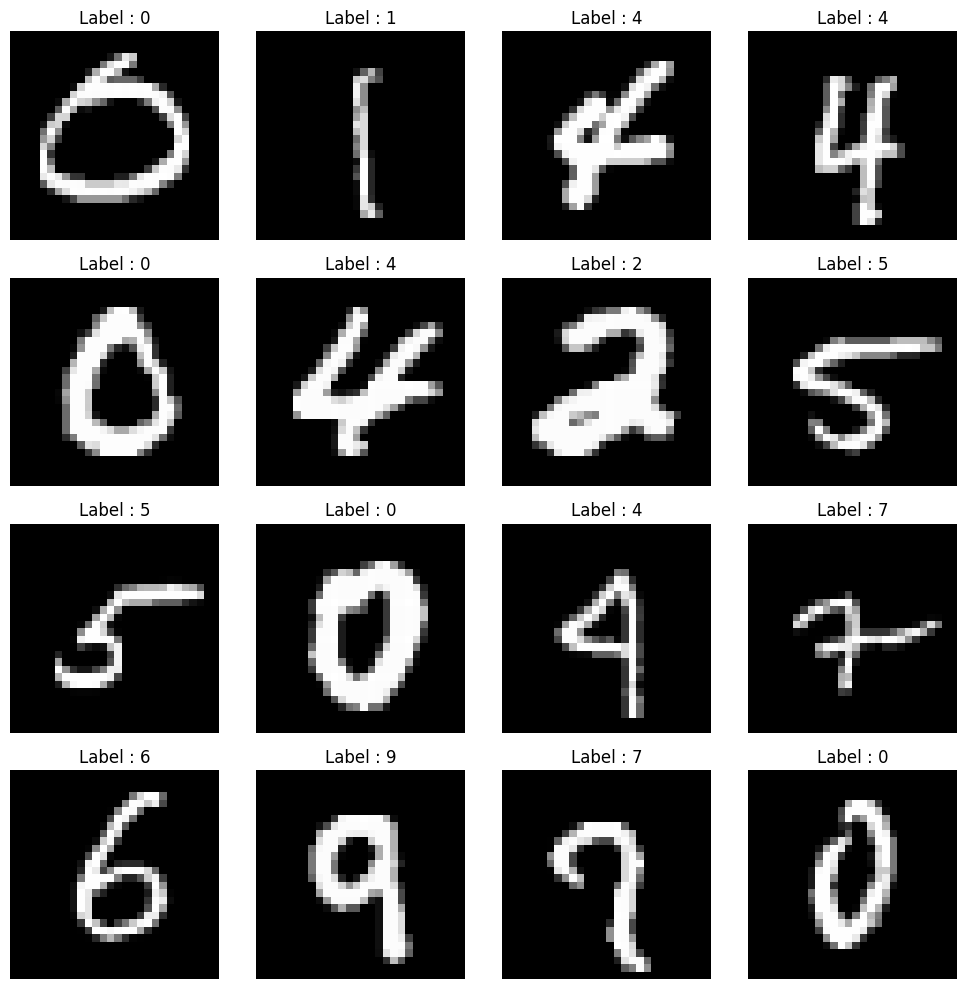

In [5]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"Label : {labels[i].item()}")

    plt.axis("off")

plt.tight_layout()

plt.show()

## Define Hyperparameters

In [6]:
batch_size = 64
learning_rate = 0.001
epochs = 5

## Build CNN Model

In [7]:
class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.conv2(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x

## Define Loss Function and Optimizer

In [8]:
model = CNN()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

## Train the CNN Model

In [9]:
for epoch in range(epochs):

    model.train()

    running_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        print(batch_idx + 1)

        running_loss += loss.item()

        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx+1}, Loss: {loss.item():.4f}")

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss:.4f}")

Streaming output truncated to the last 5000 lines.
147
148
149
150
Epoch 1, Batch 150, Loss: 0.3616
151
152
153
154
155
156
157
158
159
160
Epoch 1, Batch 160, Loss: 0.2069
161
162
163
164
165
166
167
168
169
170
Epoch 1, Batch 170, Loss: 0.1504
171
172
173
174
175
176
177
178
179
180
Epoch 1, Batch 180, Loss: 0.0956
181
182
183
184
185
186
187
188
189
190
Epoch 1, Batch 190, Loss: 0.2848
191
192
193
194
195
196
197
198
199
200
Epoch 1, Batch 200, Loss: 0.1550
201
202
203
204
205
206
207
208
209
210
Epoch 1, Batch 210, Loss: 0.2788
211
212
213
214
215
216
217
218
219
220
Epoch 1, Batch 220, Loss: 0.0669
221
222
223
224
225
226
227
228
229
230
Epoch 1, Batch 230, Loss: 0.1749
231
232
233
234
235
236
237
238
239
240
Epoch 1, Batch 240, Loss: 0.1110
241
242
243
244
245
246
247
248
249
250
Epoch 1, Batch 250, Loss: 0.2555
251
252
253
254
255
256
257
258
259
260
Epoch 1, Batch 260, Loss: 0.1225
261
262
263
264
265
266
267
268
269
270
Epoch 1, Batch 270, Loss: 0.1264
271
272
273
274
275
276


## Evaluate the Model

In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        print(batch_idx + 1)

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
Test Accuracy: 98.95%


## Predict a New Image

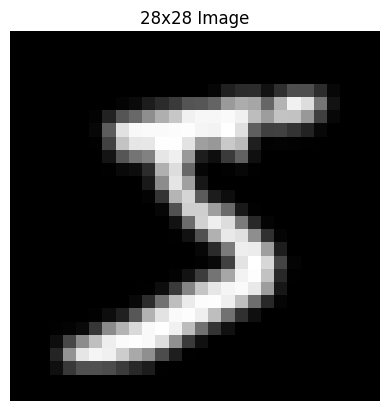

Predicted Digit: 5


In [15]:
image = Image.open("/content/digit_5.jpg").convert("L") #drop your photo

image = image.resize((28, 28))
image = transforms.ToTensor()(image)

# show the photo after preprocessing
plt.imshow(image.squeeze(), cmap="gray")
plt.title("28x28 Image")
plt.axis("off")
plt.show()

image = image.unsqueeze(0)

model.eval()

with torch.no_grad():
    output = model(image)
    prediction = torch.argmax(output, dim=1)

print("Predicted Digit:", prediction.item())

## Save the Trained Model

In [20]:
torch.save(model.state_dict(), "mnist_cnn.pth")

In [22]:
from google.colab import files

files.download("mnist_cnn.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>